# Kaggle Titanic Dataset - EDA and Binary Classifier

### [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Kaggle, https://www.kaggle.com/c/titanic

[2] Competition file mirrors, https://github.com/agconti/kaggle-titanic

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy pandas matplotlib seaborn scikit-learn
# pip install kaggle

## About This Competition

Titanic is a real Kaggle **Getting Started** competition. Getting Started competitions are permanent: they never close, have no deadline, and accept submissions at any time, so you can join today and appear on the leaderboard. The task is to predict which passengers survived. You submit a CSV with two columns, `PassengerId` and `Survived`, with one row for every passenger in the official `test.csv` (418 rows).

## Create a Kaggle Account

1. Sign up for a free account at kaggle.com.
2. Open kaggle.com/c/titanic and click **Join Competition** to accept the rules.
3. Click your profile picture, then **Settings**, then **Create New Token**.
4. A file named `kaggle.json` downloads.

## Configure the Kaggle CLI

In [2]:
# mkdir -p ~/.kaggle
# mv ~/Downloads/kaggle.json ~/.kaggle/kaggle.json
# chmod 600 ~/.kaggle/kaggle.json

## Download the Official Files With the Kaggle CLI

These commands download the exact competition files. `train.csv` has the survival labels; `test.csv` does not, because Kaggle scores your predictions against secret labels.

In [3]:
# kaggle competitions download -c titanic -f train.csv -p data
# kaggle competitions download -c titanic -f test.csv -p data
# kaggle competitions download -c titanic -f gender_submission.csv -p data

## Public Mirror Fallback

If you do not have a Kaggle token yet, this notebook downloads the same two files from a public mirror so it still runs end to end. The mirror files match the competition: `train.csv` has 891 labeled passengers and `test.csv` has 418 unlabeled passengers.

## Import Libraries

In [4]:
import os
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Seed

In [5]:
SEED = 42
SEED

42

In [6]:
torch.manual_seed(SEED)

## Download Dataset

### Function

In [7]:
def download_file(url, path):
    """
    Download a file if it is not already present.

    Parameters:
        url (str): Source URL.
        path (str): Destination path.

    Returns:
        str: The destination path.
    """
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    return path

### Run

In [8]:
MIRROR = 'https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/'
download_file(MIRROR + 'train.csv', 'data/train.csv')
download_file(MIRROR + 'test.csv', 'data/test.csv')
print('downloaded train.csv and test.csv')

downloaded train.csv and test.csv


## Load Dataset

In [9]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print('train rows:', train.shape[0])
print('test rows :', test.shape[0])

train rows: 891
test rows : 418


In [10]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

### Dataset Shape and Types

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary Statistics

In [12]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Values

`Age` and `Cabin` have many missing values. We impute `Age` and `Fare` with the training median and `Embarked` with the training mode.

In [13]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Survival Rate

In [14]:
train['Survived'].value_counts(normalize=True).round(3)

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

### Survival by Sex

Sex is the strongest single predictor: women survived far more often.

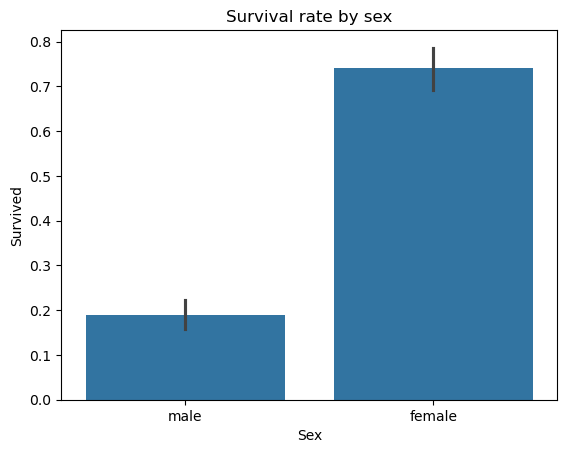

In [15]:
sns.barplot(data=train, x='Sex', y='Survived')
plt.title('Survival rate by sex')
plt.show()

### Survival by Passenger Class

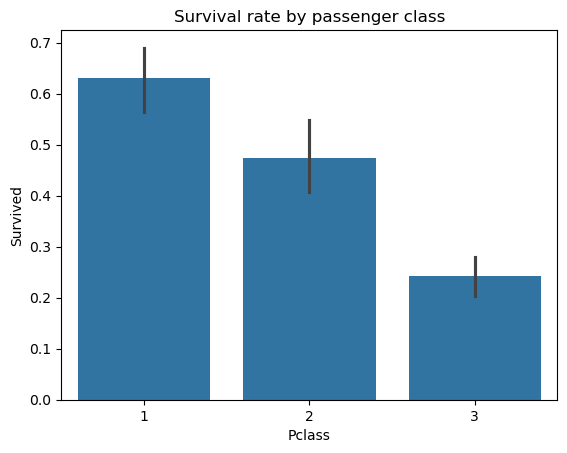

In [16]:
sns.barplot(data=train, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.show()

### Age Distribution

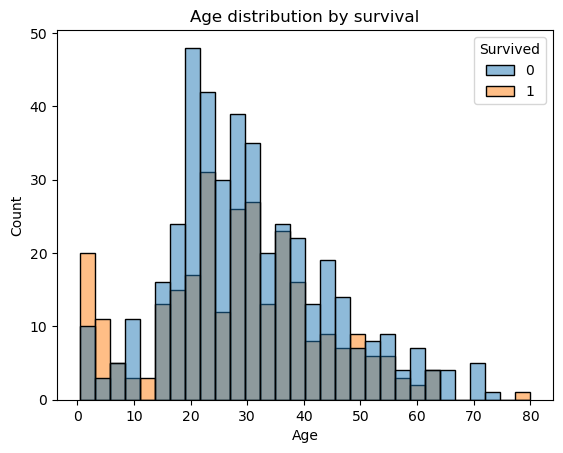

In [17]:
sns.histplot(data=train, x='Age', hue='Survived', bins=30)
plt.title('Age distribution by survival')
plt.show()

### Correlation Heatmap

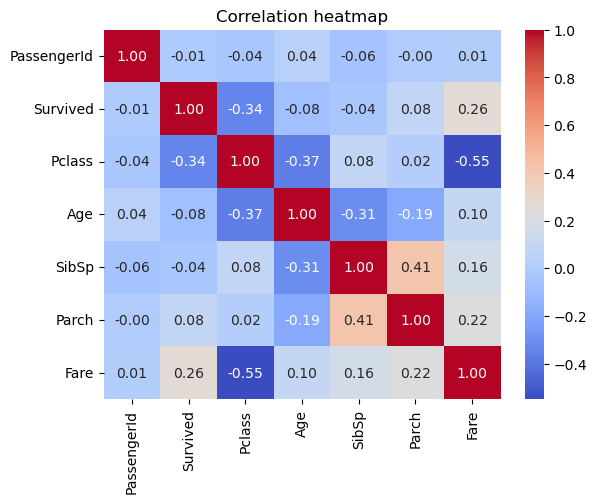

In [18]:
numeric = train.select_dtypes(include='number')
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

## Feature Engineering

We apply identical transformations to the training and test sets, using statistics computed only on the training set to avoid leakage.

### Functions

In [19]:
def add_family_features(df):
    """
    Add family size and alone features.

    Parameters:
        df (pandas.DataFrame): The Titanic data.

    Returns:
        pandas.DataFrame: The data with new features.
    """
    df = df.copy()
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    return df


def prepare_features(train, test):
    """
    Impute and encode both datasets using training statistics.

    Parameters:
        train (pandas.DataFrame): Training data with labels.
        test (pandas.DataFrame): Test data without labels.

    Returns:
        tuple: The prepared training and test data.
    """
    train = add_family_features(train)
    test = add_family_features(test)
    age_median = train['Age'].median()
    fare_median = train['Fare'].median()
    embarked_mode = train['Embarked'].mode()[0]
    for frame in (train, test):
        frame['Age'] = frame['Age'].fillna(age_median)
        frame['Fare'] = frame['Fare'].fillna(fare_median)
        frame['Embarked'] = frame['Embarked'].fillna(embarked_mode)
        frame['Sex'] = (frame['Sex'] == 'male').astype(int)
        frame['Embarked'] = frame['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    return train, test

### Run

In [20]:
train, test = prepare_features(train, test)
train[['Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked']].head()

,Sex,Age,Fare,FamilySize,IsAlone,Embarked
0,1,22.0,7.2500,2,0,0
1,0,38.0,71.2833,2,0,1
2,0,26.0,7.9250,1,1,0
3,0,35.0,53.1000,2,0,0
4,1,35.0,8.0500,1,1,0


## Prepare Features and Target

In [21]:
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked']
X = train[FEATURES].to_numpy(dtype=np.float32)
y = train['Survived'].to_numpy(dtype=np.int64)
X_test = test[FEATURES].to_numpy(dtype=np.float32)
X_MEAN = X.mean(axis=0)
X_STD = X.std(axis=0)
X = (X - X_MEAN) / X_STD
X_test = (X_test - X_MEAN) / X_STD
X.shape, X_test.shape

((891, 7), (418, 7))

## Validation Split

We hold out part of the training data to estimate performance before we build the real submission. The test set has no labels, so it cannot be used for validation.

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train.shape, X_val.shape

((712, 7), (179, 7))

## Baseline Classifier: Logistic Regression

In [23]:
baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
baseline_preds = baseline.predict(X_val)
baseline_probs = baseline.predict_proba(X_val)[:, 1]
print('accuracy:', round(accuracy_score(y_val, baseline_preds), 4))
print('roc auc :', round(roc_auc_score(y_val, baseline_probs), 4))

accuracy: 0.7933
roc auc : 0.8462


## PyTorch Classifier

### Device

In [24]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

### Create Dataset

In [25]:
class NumpyDataset(torch.utils.data.Dataset):
    """
    A memory-efficient dataset that stores data as NumPy arrays.
    """

    def __init__(self, X, y, device):
        """
        Initialize the dataset with NumPy arrays.

        Parameters:
            X (np.ndarray): Feature array.
            y (np.ndarray): Label array.
            device (torch.device): Device to move tensors to.

        Returns:
            None
        """
        self.X = X
        self.y = y
        self.device = device

    def __len__(self):
        """
        Return the number of samples in the dataset.

        Parameters:
            None

        Returns:
            int: Number of samples.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Return a single sample as tensors on the device.

        Parameters:
            idx (int): Index of the sample.

        Returns:
            tuple: Feature and label tensors.
        """
        X_tensor = torch.tensor(self.X[idx]).float().to(self.device)
        y_tensor = torch.tensor(self.y[idx]).long().to(self.device)
        return X_tensor, y_tensor

### Create Model

In [26]:
class Model(nn.Module):
    """
    A small feedforward classifier for tabular data.
    """

    def __init__(self, in_features, h1=32, h2=16, out_features=2):
        """
        Initialize the neural network layers.

        Parameters:
            in_features (int): Number of input features.
            h1 (int): Neurons in the first hidden layer.
            h2 (int): Neurons in the second hidden layer.
            out_features (int): Number of output features.

        Returns:
            None
        """
        super(Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_features))

    def forward(self, x):
        """
        Run the forward pass of the network.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output logits.
        """
        return self.net(x)

### Create DataLoaders, Loss, and Optimizer

In [27]:
train_loader = DataLoader(NumpyDataset(X_train, y_train, DEVICE),
                          batch_size=32, shuffle=True)
val_loader = DataLoader(NumpyDataset(X_val, y_val, DEVICE),
                        batch_size=32, shuffle=False)
model = Model(len(FEATURES)).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model

Model(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

### Functions

In [28]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Training Loop

In [29]:
for epoch in range(200):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_accuracy = evaluate(model, val_loader, loss_fn)
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch + 1:3d} | loss {val_loss:.4f} | accuracy {val_accuracy:.4f}")

Epoch  40 | loss 0.4529 | accuracy 0.7989


Epoch  80 | loss 0.4894 | accuracy 0.8045


Epoch 120 | loss 0.6149 | accuracy 0.7821


Epoch 160 | loss 0.7025 | accuracy 0.7598


Epoch 200 | loss 0.8675 | accuracy 0.7709


## Evaluate the PyTorch Classifier

In [30]:
_, accuracy = evaluate(model, val_loader, loss_fn)
print(f"Validation accuracy: {accuracy:.4f}")

Validation accuracy: 0.7709


In [31]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_val, dtype=torch.float32).to(DEVICE))
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
preds = (probs >= 0.5).astype(int)
print(confusion_matrix(y_val, preds))
print(classification_report(y_val, preds, target_names=['died', 'survived']))

[[96 14]
 [27 42]]
              precision    recall  f1-score   support

        died       0.78      0.87      0.82       110
    survived       0.75      0.61      0.67        69

    accuracy                           0.77       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.77      0.77      0.77       179



### ROC Curve

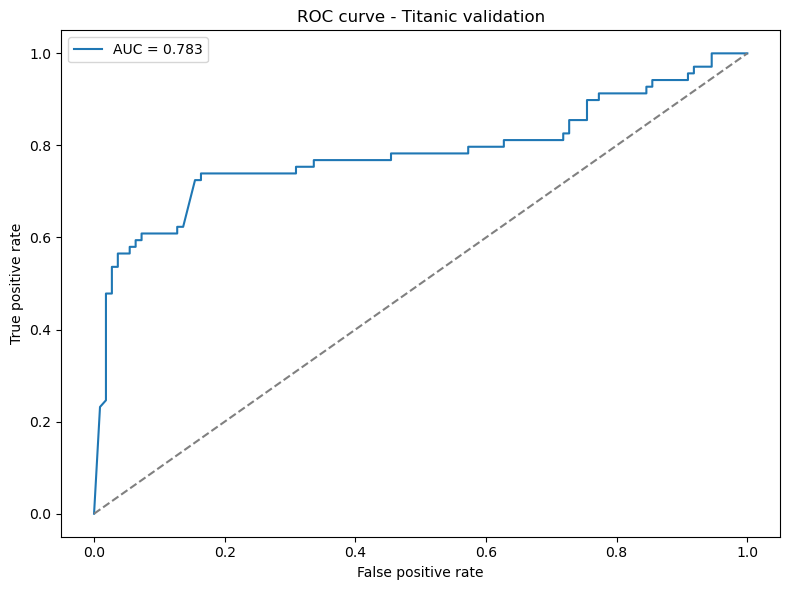

In [32]:
fpr, tpr, _ = roc_curve(y_val, probs)
auc_score = roc_auc_score(y_val, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - Titanic validation')
plt.legend()
plt.tight_layout()
plt.show()

## Predict the Real Test Set

The submission must cover the 418 passengers in the official `test.csv`. We predict on that file, not on a split of the training data.

### Function

In [33]:
def predict_test(model, X_test):
    """
    Predict survival for the official test set.

    Parameters:
        model (nn.Module): Trained model.
        X_test (numpy.ndarray): Standardized test features.

    Returns:
        numpy.ndarray: Predicted labels.
    """
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    return (probs >= 0.5).astype(int)

### Run

In [34]:
test_preds = predict_test(model, X_test)
print('test predictions:', test_preds.shape[0])

test predictions: 418


## Create the Kaggle Submission

### Function

In [35]:
def build_submission(ids, predictions, path='outputs/submission.csv'):
    """
    Write a Kaggle-format submission CSV.

    Parameters:
        ids (np.ndarray): Passenger ids from test.csv.
        predictions (numpy.ndarray): Predicted survival labels.
        path (str): Output CSV path.

    Returns:
        str: The path to the submission file.
    """
    frame = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})
    frame.to_csv(path, index=False)
    return path

### Run

In [36]:
build_submission(test['PassengerId'].to_numpy(), test_preds, 'outputs/submission.csv')
submission = pd.read_csv('outputs/submission.csv')
print('rows:', submission.shape[0])
submission.head()

rows: 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## Save Model

In [37]:
torch.save(model.state_dict(), 'models/kaggle_titanic.pt')
print('saved kaggle_titanic.pt')

saved kaggle_titanic.pt


## Load Model

In [38]:
loaded_model = Model(len(FEATURES)).to(DEVICE)
loaded_model.load_state_dict(torch.load('models/kaggle_titanic.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded kaggle_titanic.pt')

loaded kaggle_titanic.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_81227/3056722231.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('mode

## Inference

### Function

In [39]:
def predict(model, features):
    """
    Predict survival for one passenger.

    Parameters:
        model (nn.Module): Trained model.
        features (list): Raw feature values in FEATURES order.

    Returns:
        tuple: Predicted label name and probability.
    """
    model.eval()
    scaled = (np.array(features, dtype=np.float32) - X_MEAN) / X_STD
    with torch.no_grad():
        X_new = torch.tensor(scaled).float().to(DEVICE).unsqueeze(0)
        probability = torch.softmax(model(X_new), dim=1)[0, 1].item()
    label = 'survived' if probability >= 0.5 else 'died'
    return label, probability

### Run

In [40]:
label, probability = predict(loaded_model, [3, 0, 25.0, 7.25, 1, 1, 0])
print(f"Predicted: {label} (p={probability:.4f})")

Predicted: died (p=0.4490)


## Submit to the Leaderboard

1. Open kaggle.com/c/titanic and click **Submit Predictions**.
2. Upload `submission.csv`.
3. Read your score on the public leaderboard.
4. Improve your features and submit again. There is no deadline; the competition never closes.